In [1]:
# We are plotting QITE sim for 8 spins with initial spins set to 0. We want to see how quickly it converges to the ground state energy
import matplotlib.pyplot as plt
import numpy as np


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Load 6 timesteps
qite_file = "/home/jkalloor/bqskit/good_blocks_tket/QITE_8_{timestep}_0.qasm"

timesteps = range(5)
energies = []
circs = []
for t_step in timesteps:
    circ = QuantumCircuit.from_qasm_file(qite_file.format(timestep=t_step))
    # circ.measure_all()
    circ.save_density_matrix()
    circs.append(circ)

In [3]:
# Def calculation of Hamiltonian
import scipy.linalg as la
#Pauli matrices
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
#setup inital hamiltonian

#number of samples
T = 100
nmetts = T+10
#number of qubits
N = 8
#Hamiltonian parameters
Jz = 1.0 #ising interaction strength
mu_x = 1.0 #transverse magnetic field strength

def gen_hamiltonian(num_qubits: int = 8, Jz = 1.0, mu_x = 1.0):
    """Generate the Hamiltonian for the system."""
    #initial Hamiltonian
    #size of matrix
    msize = 2 ** num_qubits
    ham = np.zeros((msize, msize), dtype=np.complex128)
    # Ising interaction in 1D line
    for i in range(num_qubits-1):
        ising_term = np.kron(sz, sz)
        # left term
        if i > 0:
            ising_term = np.kron(np.eye(2**i), ising_term)
        if i < num_qubits - 2:
            qubits_right = num_qubits - i - 2
            ising_term = np.kron(ising_term, np.eye(2**qubits_right))
        # add to Hamiltonian
        ham += Jz * ising_term

        transverse_term = np.kron(sx, np.eye(2 ** (num_qubits -i - 1)))
        if i > 0:
            transverse_term = np.kron(np.eye(2**i), transverse_term)
        
        ham += mu_x * transverse_term
    # add the last term
    ham += mu_x * np.kron(np.eye(2**(num_qubits-1)), sx)
    return ham

#initial Hamiltonian
ham = gen_hamiltonian(num_qubits=N, Jz=Jz, mu_x=mu_x)
#ground state energy
eigvals_i, eigvecs_i = la.eig(ham)
gs_eng = np.real(min(eigvals_i))
print("Ground state energy: ", gs_eng)

Ground state energy:  -9.83795144745944


In [4]:
# For each circ, simulate the output and calculate the energy
from qiskit_aer import AerSimulator
from util.counter import fix_angle_workflow
from bqskit.ir import Circuit
from math import ceil
from bqskit.ext import bqskit_to_qiskit

# Lambda function to calculate energy
eng_func = lambda sv: np.real(np.trace(ham @ sv))

def calculate_gs(circs: list[QuantumCircuit]):
    sim = AerSimulator(method="density_matrix")
    result = sim.run(circs).result()
    # counts = result.get_counts(circ)
    # print(result.data(0))
    svs = [result.data(i)['density_matrix'].data for i in range(len(circs))]
    # Calculate the energy
    engs = [eng_func(sv) for sv in svs]
    return np.mean(engs)

def get_qcirc(circ: Circuit) -> QuantumCircuit:
    circ.unfold_all()
    # Remove all GlobalPhaseGates
    return bqskit_to_qiskit(circ)

default_precision = 6

energies = []
precisions = []
circs = []
for t_step in timesteps:
    b_circ = Circuit.from_file(qite_file.format(timestep=t_step))
    fix_angle_workflow(b_circ, default_precision)
    precisions.append(default_precision + ceil(np.log10(b_circ.num_params)))
    print(b_circ.gate_counts)
    circ = get_qcirc(b_circ)

    # circ = QuantumCircuit.from_qasm_file(qite_file.format(timestep=t_step))
    # circ.measure_all()
    circ.save_density_matrix()
    circs.append(circ)

print("Precisions: ", precisions)
# energies = [-6.2, -8.9, -8.9, -9.2, -9.4, -9.4, -9.4]

{TdgGate: 1, ZGate: 34, RZGate: 283, CNOTGate: 97, TGate: 4, SGate: 327, HGate: 590, SdgGate: 86}
{TdgGate: 3, ZGate: 61, RZGate: 682, CNOTGate: 215, TGate: 7, SGate: 678, HGate: 1236, SdgGate: 129}
{TdgGate: 3, ZGate: 83, RZGate: 1136, CNOTGate: 335, TGate: 7, SGate: 1060, HGate: 1944, SdgGate: 169}
{TdgGate: 3, ZGate: 104, RZGate: 1590, CNOTGate: 455, TGate: 7, SGate: 1442, HGate: 2654, SdgGate: 211}
{TdgGate: 3, ZGate: 128, RZGate: 2044, CNOTGate: 575, TGate: 7, SGate: 1824, HGate: 3358, SdgGate: 247}
Precisions:  [9, 9, 10, 10, 10]


In [5]:
# Calculate the energies
# energies = [eng_func(sv) for sv in svs]
energies = [calculate_gs([circ]) for circ in circs]

In [6]:
# Def noise model
from qiskit_aer.noise import NoiseModel, pauli_error

T_ERR_RATE = 1e-7

def get_noise_model(precision = 8, t_err = 1e-5):
    noise_model = NoiseModel()
    # Add depolarizing error
    # An RZ decomposes in 10 * precision T gates
    t_fid = 1 - t_err
    num_ts_per_rz = 10 * precision
    rz_fid = (t_fid ** num_ts_per_rz)
    rz_err = 1 - rz_fid
    err = pauli_error([('X', rz_err / 3), ('Y', rz_err / 3), ('Z', rz_err / 3), ('I', rz_fid)])
    err_t = pauli_error([('X', t_err / 3), ('Y', t_err / 3), ('Z', t_err / 3), ('I', t_fid)])

    noise_model.add_all_qubit_quantum_error(err, ['rz', 'u3'])
    noise_model.add_all_qubit_quantum_error(err_t, ['t'])

    return noise_model

def calculate_gs_with_noise(circs: list[QuantumCircuit], 
                            precisions: list[int],
                            t_err = 1e-7):
    svs = []
    for i, circ in enumerate(circs):
        prec = precisions[i]
        # circ.metadata = {"precision": precisions[i]}
        noise_model = get_noise_model(prec, t_err)
        sim = AerSimulator(method="density_matrix", noise_model=noise_model)
        result = sim.run(circ).result()
        svs.append(result.data(0)['density_matrix'].data)
    # Calculate the energy
    engs = [eng_func(sv) for sv in svs]
    return np.mean(engs), np.std(engs)

# For each circ, simulate the output and calculate the energy
noisy_energies = []
for circ in circs:
    eng = calculate_gs_with_noise([circ], precisions, T_ERR_RATE)
    noisy_energies.append(eng)
    print(f"Energy for timestep {len(noisy_energies)-1}: {eng}")

Energy for timestep 0: (-6.218009823648364, 0.0)
Energy for timestep 1: (-9.099791681308563, 0.0)
Energy for timestep 2: (-9.53913326954981, 0.0)
Energy for timestep 3: (-9.547988576916644, 0.0)
Energy for timestep 4: (-9.528862630497448, 0.0)


In [7]:
import pickle
ensemble_sizes = [32, 64, 128, 256, 512]
t_errs = [1e-2, 1e-3, 1e-7]
sizes = "_".join([str(s) for s in ensemble_sizes])
t_err_str = "_".join([str(t) for t in t_errs])
ens_energies = pickle.load( open(f"ens_energies_3.0_{sizes}_{t_err_str}_0_4.pkl", "rb"))

In [8]:
for ens_size in ensemble_sizes:
    data = ens_energies[ens_size]
    print([x[T_ERR_RATE] for x in data])

[(-6.221286452724705, 0.0003139514808133936), (-9.110307377713127, 0.0004211310070077153), (-9.558423634853675, 0.0003048877398963113), (-9.575377151386625, 0.0006012990776425114), (-9.56122744117976, 0.0007613136832824734)]
[(-6.221372842586605, 0.00064877084417347), (-9.110233471938212, 0.00045515316713125276), (-9.558450374647467, 0.00030387320632948325), (-9.575323083843323, 0.0006275826955899009), (-9.561496534610338, 0.0009825084481459598)]
[(-6.221274776271594, 0.000620283755128435), (-9.110286087111865, 0.00047236442121767865), (-9.558510177930529, 0.0003777441110633115), (-9.575359926063294, 0.0006630731626840272), (-9.561379299803441, 0.0008807346584478939)]
[(-6.221354890884821, 0.0006377950554912641), (-9.110242572297434, 0.00048577317800861094), (-9.558504942609531, 0.0003704229855359854), (-9.575244379756551, 0.0007166654263351337), (-9.56138042098381, 0.0008326336877987649)]
[(-6.221356167185585, 0.00042097308853187356), (-9.110242134974191, 0.0004710949643087768), (-9.5

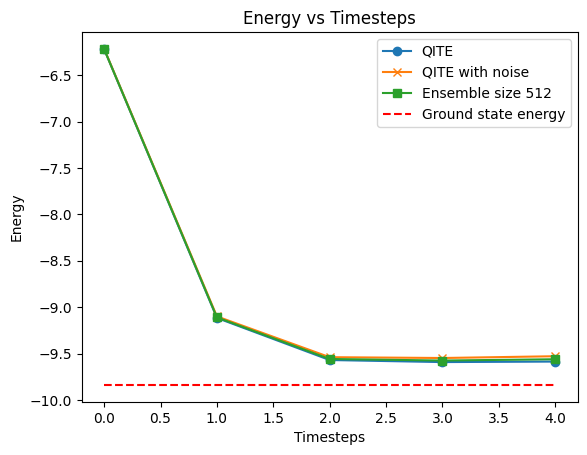

In [12]:
# Plot the results
fig, ax = plt.subplots()
ax.plot(timesteps, energies, label='QITE', marker='o')
noisy_data = [x[0] for x in noisy_energies]
ax.plot(timesteps, noisy_data, label='QITE with noise', marker='x')
ens_size = 512
ens_data = [x[T_ERR_RATE][0] for x in ens_energies[ens_size]]
ax.plot(timesteps, ens_data, label=f'Ensemble size {ens_size}', marker='s')
ax.hlines(gs_eng, 0, 4, colors='r', linestyles='dashed', label='Ground state energy')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Energy')
ax.set_title('Energy vs Timesteps')
ax.legend()
# plt.show()
plt.savefig(f"qite_sim_512_{T_ERR_RATE}.png", dpi=300)
# ax.plot(timesteps, ens_energies, label='Ensemble', marker='s')

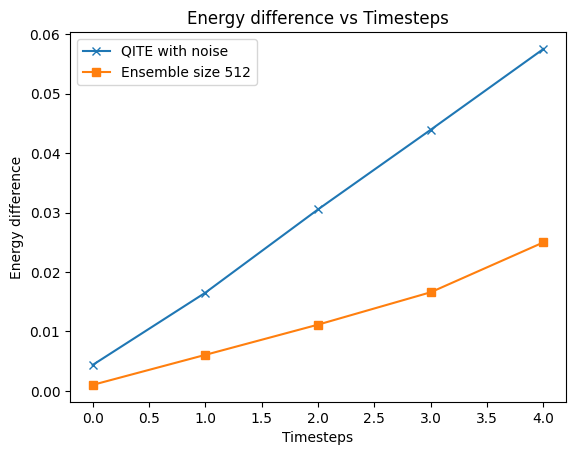

In [13]:
# Now plot the differences

noisy_diffs = np.array(noisy_data) - np.array(energies)
ens_diffs = np.array(ens_data) - np.array(energies)
fig, ax = plt.subplots()
ax.plot(timesteps, noisy_diffs, label='QITE with noise', marker='x')
ax.plot(timesteps, ens_diffs, label=f'Ensemble size {ens_size}', marker='s')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Energy difference')
ax.set_title('Energy difference vs Timesteps')
ax.legend()
# plt.show()